## Modelos Baseline SARIMA y SARIMAX — Sistema de Predicción Energética en Barcelona

> **Contexto:** A partir de `dataset_features` (notebooks 03 y 04), se construyen los modelos
> **baseline** del TFM: **SARIMA** (univariante) y **SARIMAX** (con variables exógenas). Son la
> referencia contra la que se compararán XGBoost/LightGBM y LSTM/GRU en fases posteriores.

### Directiva de modelado (tutoría José, obligatoria)

- Baseline = **SARIMA y SARIMAX** únicamente (Prophet descartado).
- **Test = 2025 más reciente** (oct–nov, datos terminan 2025-11-30); **nunca se toca**.
- Métrica **primaria = R²** (maximizar); reportar también MAE, RMSE, MAPE.
- Grid search: **NO usar `best_model` directo** → guardar todo en CSV, calcular la diferencia
  relativa R²_train vs R²_val, graficar overfitting y elegir **mejor R²_val con rel_diff ≤ 0.10**.
- Documentar **ADF + KPSS**.

### Estrategia de validación (train / validación / test)

| Conjunto | Fechas | Uso |
|---|---|---|
| **Train** | 2019-01 → 2024-12 | Ajuste + R²_train (in-sample) |
| **Validación** | 2025-01 → 2025-09 | Grid search: R²_val + control de overfitting |
| **Test** | 2025-10 → 2025-11 | Backtesting final out-of-sample (intacto) |

- **Walk-forward backtesting** (igual que skforecast en las fuentes py29/py51), horizonte **72h = 12 bloques**.
- **Grid search** sobre los **4 CPs representativos** (08038, 08005, 08032, 08002); el backtest final
  se aplica a los **42 CPs** con los órdenes seleccionados.
- Órdenes seed del EDA (ACF/PACF): `d=0, D=1, s=28; p≈3-4, q≈1, P=Q=1`.

> ⚠️ **Caveat (presente, no tratado aún):** el target del CP **08037** (jul–nov 2025) es imputado
> (sintético) y cae dentro de validación y test. Sus métricas no reflejan demanda real; se decidirá
> más adelante si se trata aparte o se excluye.

## Librerías

In [2]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymongo import MongoClient
import warnings, time

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#D3D3D3'
plt.rcParams['grid.linewidth'] = 0.4
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta de color
C1 = '#264653'; C2 = '#2A9D8F'; C3 = '#E9C46A'
C4 = '#F4A261'; C5 = '#E76F51'; C6 = '#A8DADC'
TITULO = '#1B3A5C'; SUBTITULO = '#C0392B'

start_time = time.time()

In [3]:
client = MongoClient('mongodb://mongo:27017/')
db     = client['tfm_energy']

docs = list(db['dataset_features'].find({}, {'_id': 0}))
df   = pl.DataFrame(docs, infer_schema_length=None)

print(f"Shape: {df.shape}")
print(f"Desde: {df['datetime'].min()}  Hasta: {df['datetime'].max()}")
print(f"Codigos postales: {df['cod_postal'].n_unique()}")

Shape: (424368, 43)
Desde: 2019-01-01 00:00:00  Hasta: 2025-11-30 18:00:00
Codigos postales: 42


---
# <font color='#1B3A5C'>  **1. Configuración del Experimento** </font>

> Se fijan las fechas de corte, el horizonte, los CPs y las funciones que extraen cada serie.
> Estos parámetros son **idénticos para todos los modelos** (SARIMA, SARIMAX y los de fases
> posteriores), lo que garantiza una comparación directa y justa.

In [4]:
# Cortes temporales (índice de bloques de 6h)
FIN_TRAIN = '2024-12-31 18:00:00'   # train: 2019 -> 2024
FIN_VAL   = '2025-09-30 18:00:00'   # validacion: 2025-01 -> 2025-09
# test: 2025-10-01 -> 2025-11-30 (lo que queda tras FIN_VAL)

# Horizonte de predicción
STEPS = 12          # 72h (principal).  STEPS = 4 -> 24h (alternativo)
S = 28              # periodo estacional semanal (4 bloques/dia * 7)

# Estacionalidad / órdenes seed del EDA
SEED_ORDER    = (3, 0, 1)
SEED_SORDER   = (1, 1, 1, S)

# CPs
CPS_REPR = ['08038', '08005', '08032', '08002']   # grid search (4 perfiles del EDA)
CPS_TODOS = sorted(df['cod_postal'].unique().to_list())  # backtest final (42)

print(f"Train  : 2019-01-01 -> {FIN_TRAIN}")
print(f"Val    : 2025-01-01 -> {FIN_VAL}")
print(f"Test   : 2025-10-01 -> {df['datetime'].max()}")
print(f"Horizonte: {STEPS} bloques ({STEPS*6}h) | s = {S}")
print(f"CPs grid: {CPS_REPR} | CPs total: {len(CPS_TODOS)}")

Train  : 2019-01-01 -> 2024-12-31 18:00:00
Val    : 2025-01-01 -> 2025-09-30 18:00:00
Test   : 2025-10-01 -> 2025-11-30 18:00:00
Horizonte: 12 bloques (72h) | s = 28
CPs grid: ['08038', '08005', '08032', '08002'] | CPs total: 42


In [5]:
# Extrae la serie mwh_total de un CP como pandas Series con frecuencia de 6h
def get_serie(cp):
    s = (df.filter(pl.col('cod_postal') == cp)
           .sort('datetime')
           .select(['datetime', 'mwh_total'])
           .to_pandas().set_index('datetime')['mwh_total'])
    return s.asfreq('6h')

# Comprobación rápida
_s = get_serie('08002')
print(f"08002 -> {len(_s)} bloques, nulos: {_s.isna().sum()}")
print(_s.head(3))

08002 -> 10104 bloques, nulos: 0
datetime
2019-01-01 00:00:00    101754.0
2019-01-01 06:00:00    113491.0
2019-01-01 12:00:00    125263.0
Freq: 6h, Name: mwh_total, dtype: float64


---
# <font color='#1B3A5C'>  **2. Funciones del Arnés de Evaluación** </font>

> Tres funciones reutilizables que definen la comparación: el cálculo de métricas (R² primaria),
> el ajuste de un SARIMAX y el **backtesting walk-forward**. El backtest ajusta el modelo una vez
> sobre el train y luego avanza por el periodo de evaluación actualizando el estado con las
> observaciones reales (`append`), tal como recomienda la fuente py51 para modelos estadísticos.

In [ ]:
def metricas(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    denom = np.where(y_true == 0, np.nan, y_true)
    return {
        'r2'  : r2_score(y_true, y_pred),
        'mae' : mean_absolute_error(y_true, y_pred),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mape': float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100),
    }


def _freq6(x):
    # El slicing .loc/.iloc descarta el freq del DatetimeIndex; SARIMAX y .extend()
    # exigen un indice con frecuencia continua, asi que la reasignamos (6h).
    if x is None:
        return None
    x = x.copy()
    try:
        x.index.freq = x.index.inferred_freq or '6h'
    except (ValueError, TypeError):
        x = x.asfreq('6h')
    return x


def ajustar_sarimax(serie, order, seasonal_order, exog=None):
    serie = _freq6(serie); exog = _freq6(exog)
    mod = SARIMAX(serie, exog=exog, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False)
    return mod.fit(disp=False)


def backtest(res, serie_eval, steps, exog_eval=None, refit=False):
    serie_eval = _freq6(serie_eval); exog_eval = _freq6(exog_eval)
    y_true, y_pred = [], []
    n = len(serie_eval); i = 0
    while i < n:
        h = min(steps, n - i)
        ex_f = exog_eval.iloc[i:i+h] if exog_eval is not None else None
        fc = np.asarray(res.forecast(steps=h, exog=ex_f))[:h]
        y_pred.extend(fc); y_true.extend(np.asarray(serie_eval.iloc[i:i+h]))
        ex_a = exog_eval.iloc[i:i+h] if exog_eval is not None else None
        nuevos = serie_eval.iloc[i:i+h]
        if refit:
            res = res.append(nuevos, exog=ex_a, refit=True)
        else:
            res = res.extend(nuevos, exog=ex_a)   # actualiza estado SIN reajustar (estandar)
        i += h
    return np.array(y_true), np.array(y_pred)

---
# <font color='#1B3A5C'>  **3. Pruebas de Estacionariedad (ADF + KPSS)** </font>

> Requisito de José: documentar ADF y KPSS. Se confirman sobre la serie de cada CP representativo
> antes de modelar (el EDA ya lo hizo a nivel global). Recordatorio:
- **ADF** — H0: la serie NO es estacionaria (raíz unitaria). p < 0.05 → estacionaria en media.
- **KPSS** — H0: la serie SÍ es estacionaria. p < 0.05 → NO estacionaria (en varianza).

In [7]:
filas = []
for cp in CPS_REPR:
    serie = get_serie(cp).loc[:FIN_VAL].dropna()
    adf_p  = adfuller(serie, autolag='AIC')[1]
    kpss_p = kpss(serie, regression='c', nlags='auto')[1]
    filas.append({
        'cp': cp,
        'ADF_p': round(adf_p, 4),  'ADF': 'estacionaria' if adf_p < 0.05 else 'no',
        'KPSS_p': round(kpss_p, 4), 'KPSS': 'estacionaria' if kpss_p > 0.05 else 'no',
    })
print(pd.DataFrame(filas).to_string(index=False))

   cp  ADF_p          ADF  KPSS_p         KPSS
08038 0.0000 estacionaria  0.0769 estacionaria
08005 0.0001 estacionaria  0.0100           no
08032 0.0000 estacionaria  0.0100           no
08002 0.0016 estacionaria  0.0100           no


> Resultado esperado (coherente con el EDA): **ADF estacionaria en media** (p<0.05) y **KPSS
> rechaza** (p<0.05) → estacionariedad parcial. Por eso se usa diferenciación **estacional** (`D=1`)
> pero no regular (`d=0`) en SARIMA.

---
# <font color='#1B3A5C'>  **4. Baseline: Naive Estacional** </font>

> Modelo de referencia mínimo (igual que `ForecasterEquivalentDate` en py29): predice cada bloque
> con el valor del **mismo bloque de hace 1 semana** (`shift(28)`). Si SARIMA no le gana, no aporta.

In [8]:
filas = []
for cp in CPS_TODOS:
    serie = get_serie(cp)
    test  = serie.loc[FIN_VAL:].iloc[1:]          # oct-nov 2025
    pred  = serie.shift(S).loc[test.index]        # valor de hace 1 semana
    m = metricas(test.values, pred.values); m['cp'] = cp
    filas.append(m)

base_res = pd.DataFrame(filas)
print("Baseline naive estacional (test oct-nov 2025) — resumen 42 CPs")
print(base_res[['r2', 'mae', 'rmse', 'mape']].mean().round(3))
print(base_res[['r2','mae','rmse','mape']].median().round(3))   # mediana

Baseline naive estacional (test oct-nov 2025) — resumen 42 CPs
r2          0.448
mae      9620.521
rmse    14089.107
mape       25.864
dtype: float64
r2          0.677
mae      8289.963
rmse    12345.358
mape        9.924
dtype: float64


In [9]:
# Tabla por CP, de mejor a peor R²
pd.set_option('display.max_rows', 50)
print(base_res.sort_values('r2', ascending=False)[['cp','r2','mae','rmse','mape']].round(2).to_string(index=False))

# Distribución real (en vez de solo la media)
print("\nDistribución de R² entre los 42 CPs:")
print(base_res['r2'].describe().round(3))

# 08037 (el imputado, sospechoso de arrastrar la media)
print("\n08037:", base_res[base_res['cp']=='08037'][['cp','r2','mae','mape']].to_dict('records'))

   cp    r2      mae     rmse   mape
08008  0.88  3973.61  6246.18   6.36
08001  0.87  4828.33  7248.01   5.67
08002  0.84  8493.69 11568.62   9.31
08018  0.81 10138.78 14546.18   7.93
08006  0.81  3661.56  5266.12   9.19
08003  0.80  9539.85 12373.49   7.28
08017  0.80  5781.26  9136.67   6.35
08030  0.79 16244.32 21957.91   7.74
08012  0.78  4422.69  6746.70   7.93
08028  0.78 11635.83 15774.97   7.52
08038  0.78 14369.22 22214.56   6.73
08014  0.75  9860.60 12317.22  10.09
08015  0.75  6854.83  9383.37   8.97
08022  0.74  9253.02 12819.79  10.45
08025  0.74 14751.08 19003.64   9.76
08032  0.73  4925.68  7417.77   8.36
08020  0.73 10133.77 13192.11   6.85
08016  0.72  6406.05  8537.10  11.27
08034  0.71 10193.33 13079.87   7.22
08042  0.69  7252.39  9675.53   9.51
08019  0.69  5821.27  8878.93   8.73
08035  0.67  7016.45 10486.25   7.98
08041  0.62  9301.63 13682.62  10.20
08031  0.62  5064.34  7111.84  12.35
08027  0.60  7656.30 12907.92   8.98
08010  0.59  2298.44  3261.23  13.40
0

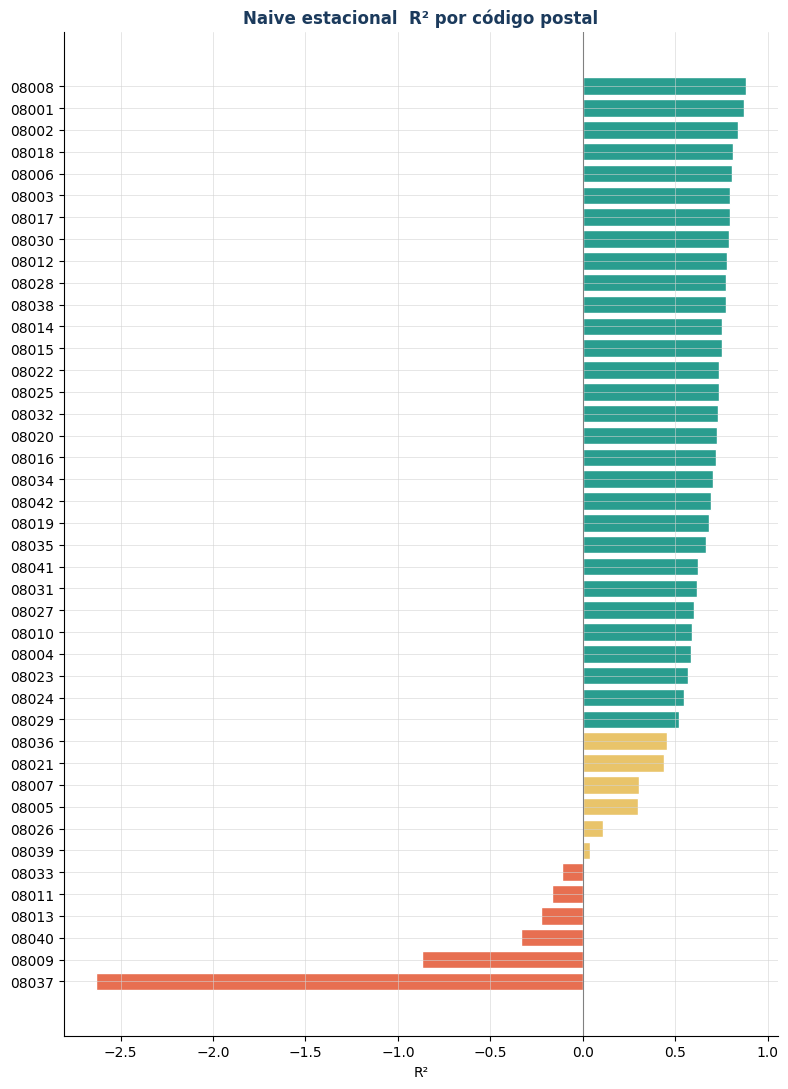

In [10]:
b = base_res.sort_values('r2')
colores = [C5 if r < 0 else (C3 if r < 0.5 else C2) for r in b['r2']]
fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(b['cp'], b['r2'], color=colores, edgecolor='white')
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('R²'); ax.set_title('Naive estacional  R² por código postal', fontweight='bold', color=TITULO)
plt.tight_layout(); plt.show()

---
# <font color='#1B3A5C'>  **5. SARIMA  Grid Search (4 CPs representativos)** </font>

> Se prueba una rejilla de órdenes (sembrada por el ACF/PACF del EDA) sobre los 4 perfiles.
> Para **cada** combinación se guarda **R²_train (in-sample) y R²_val (backtest)** → CSV.
> La selección sigue la regla de José: **no** se toma el mejor sin más.

> ⚠️ **Cómputo:** SARIMAX con `s=28` es lento. Esta celda ajusta `len(ORDERS)×len(SORDERS)×4`
> modelos. Prueba primero con 1 CP / pocas combinaciones y luego amplía.

In [ ]:
# Grid search SARIMA segun directiva 4 de Jose: probar TODAS las combinaciones
# sobre los 4 CPs representativos y guardar todo en CSV (no usar best_model directo).
ORDERS  = [(2, 0, 1), (3, 0, 1), (3, 0, 2), (4, 0, 1)]
SORDERS = [(1, 1, 1, S), (0, 1, 1, S), (1, 1, 0, S)]

filas = []
for cp in CPS_REPR:
    serie = get_serie(cp)
    s_tr = serie.loc[:FIN_TRAIN]
    s_va = serie.loc[FIN_TRAIN:FIN_VAL].iloc[1:]      # validacion 2025-01..09
    for order in ORDERS:
        for so in SORDERS:
            try:
                res = ajustar_sarimax(s_tr, order, so)
                r2_tr = r2_score(s_tr.iloc[S:], res.fittedvalues.iloc[S:])
                yt, yp = backtest(res, s_va, STEPS)
                r2_va = r2_score(yt, yp)
                rel = (r2_tr - r2_va) / abs(r2_tr) if r2_tr != 0 else np.nan
                filas.append({'cp': cp, 'order': str(order), 'seasonal': str(so),
                              'r2_train': round(r2_tr, 4), 'r2_val': round(r2_va, 4),
                              'rel_diff': round(rel, 4),
                              'mae_val': round(mean_absolute_error(yt, yp), 1)})
                print(f"{cp} {order}x{so}: R2_tr={r2_tr:.3f} R2_val={r2_va:.3f} rel={rel:.3f}")
            except Exception as e:
                filas.append({'cp': cp, 'order': str(order), 'seasonal': str(so),
                              'error': str(e)[:60]})
                print(f"{cp} {order}x{so}: ERROR {str(e)[:50]}")

res_grid = pd.DataFrame(filas)
res_grid.to_csv('grid_sarima.csv', index=False)
print(f"Guardado grid_sarima.csv ({len(res_grid)} filas)")

### <font color='#C0392B'><b>5.1 Selección con control de overfitting</b></font>

> Regla de José: descartar combinaciones con `rel_diff > 0.10` (overfitting) y, entre las que
> quedan, elegir la de **mayor R²_val**. Se promedia entre los 4 CPs para fijar un orden común.

In [12]:
UMBRAL_REL_DIFF = 0.10

ok = res_grid.dropna(subset=['r2_val']) if 'r2_val' in res_grid else res_grid
agg = (ok.groupby(['order', 'seasonal'])
         .agg(r2_val=('r2_val', 'mean'), rel_diff=('rel_diff', 'mean'),
              mae_val=('mae_val', 'mean'))
         .reset_index())

candidatos = agg[agg['rel_diff'] <= UMBRAL_REL_DIFF]
print("Candidatos sin overfitting (rel_diff <= 0.10):")
print(candidatos.sort_values('r2_val', ascending=False).to_string(index=False))

best = candidatos.sort_values('r2_val', ascending=False).iloc[0]
print(f"\nSeleccionado -> order={best['order']} seasonal={best['seasonal']} "
      f"(R2_val={best['r2_val']:.3f}, rel_diff={best['rel_diff']:.3f})")

KeyError: "Column(s) ['mae_val', 'r2_val', 'rel_diff'] do not exist"

In [ ]:
# Gráfico overfitting: R2_val vs rel_diff
fig, ax = plt.subplots(figsize=(10, 6))
colores = [C5 if r > UMBRAL_REL_DIFF else C2 for r in agg['rel_diff']]
ax.scatter(agg['rel_diff'], agg['r2_val'], c=colores, s=90, edgecolors='white', zorder=3)
for _, r in agg.iterrows():
    ax.annotate(f"{r['order']}\n{r['seasonal']}", (r['rel_diff'], r['r2_val']),
                fontsize=6, alpha=0.7, ha='center')
ax.axvline(UMBRAL_REL_DIFF, color=C5, linestyle='--', linewidth=1)
ax.text(UMBRAL_REL_DIFF + 0.002, ax.get_ylim()[0], 'umbral 0.10', color=C5, fontsize=8)
ax.set_xlabel('Diferencia relativa R²_train vs R²_val (overfitting →)')
ax.set_ylabel('R²_val (media 4 CPs)')
ax.set_title('Selección de órdenes SARIMA — R²_val vs overfitting', fontweight='bold', color=TITULO)
plt.tight_layout(); plt.show()

> Verde = combinaciones aceptables (`rel_diff ≤ 0.10`); rojo = overfitting. Se elige el punto
> verde más alto. **Fija el orden seleccionado en la celda siguiente** antes del backtest de los 42 CPs.

---
# <font color='#1B3A5C'>  **6. SARIMA — Backtesting Final (42 CPs)** </font>

> Con el orden seleccionado, se ajusta un SARIMA por CP sobre **train+validación** y se hace el
> backtesting sobre el **test (oct–nov 2025)**, intacto.

In [ ]:
# <-- Ajusta estos valores según la selección de la sección 5.1
ORDER_SEL  = SEED_ORDER          # p.ej. (3, 0, 1)
SORDER_SEL = SEED_SORDER         # p.ej. (1, 1, 1, 28)

filas = []
for cp in CPS_TODOS:
    serie = get_serie(cp)
    s_trv = serie.loc[:FIN_VAL]           # train + validacion
    s_te  = serie.loc[FIN_VAL:].iloc[1:]  # test oct-nov 2025
    try:
        res = ajustar_sarimax(s_trv, ORDER_SEL, SORDER_SEL)
        yt, yp = backtest(res, s_te, STEPS)
        m = metricas(yt, yp); m['cp'] = cp
        filas.append(m)
        print(f"{cp}: R2={m['r2']:.3f} MAE={m['mae']:.0f} MAPE={m['mape']:.1f}%")
    except Exception as e:
        print(f"{cp}: ERROR {str(e)[:50]}")

sarima_res = pd.DataFrame(filas)
print("\nSARIMA — resumen 42 CPs (media):")
print(sarima_res[['r2', 'mae', 'rmse', 'mape']].mean().round(3))

---
# <font color='#1B3A5C'>  **7. SARIMAX — Con Variables Exógenas** </font>

> SARIMAX = SARIMA + regresores externos conocidos en el momento de predecir:
- **Clima:** `temp_mean`, `HDD`, `CDD`, `humedad_mean` (supuesto: pronóstico perfecto).
- **Calendario:** `es_festivo`, `is_covid`.
- **Ciclo diario:** términos de Fourier de la hora (`sin_dia`, `cos_dia`) — capturan la
  estacionalidad diaria (s=4) que el SARIMA semanal (s=28) no modela.

> Los **lags** (lag_1…lag_28, rolling) NO entran: la autorregresión la hace SARIMA internamente.

In [ ]:
EXOG_COLS = ['HDD', 'CDD', 'humedad_mean', 'es_festivo', 'is_covid']  # temp_mean fuera: colineal con HDD/CDD (Spearman 0.81-0.86) -> inestabilidad en SARIMAX lineal

def get_exog(cp):
    e = (df.filter(pl.col('cod_postal') == cp)
           .sort('datetime')
           .select(['datetime', 'hora'] + EXOG_COLS)
           .to_pandas().set_index('datetime').asfreq('6h'))
    e = e.ffill().bfill()                      # rellena nulos residuales de meteo
    ang = 2 * np.pi * e['hora'] / 24           # Fourier diario (periodo 24h)
    e['sin_dia'] = np.sin(ang); e['cos_dia'] = np.cos(ang)
    return e.drop(columns=['hora'])

# Comprobación
_e = get_exog('08002')
print(f"exog 08002: {_e.shape}, nulos: {int(_e.isna().sum().sum())}")
print(list(_e.columns))

In [ ]:
filas = []
for cp in CPS_TODOS:
    serie = get_serie(cp); exog = get_exog(cp)
    s_trv = serie.loc[:FIN_VAL];        e_trv = exog.loc[:FIN_VAL]
    s_te  = serie.loc[FIN_VAL:].iloc[1:]; e_te = exog.loc[FIN_VAL:].iloc[1:]
    try:
        res = ajustar_sarimax(s_trv, ORDER_SEL, SORDER_SEL, exog=e_trv)
        yt, yp = backtest(res, s_te, STEPS, exog_eval=e_te)
        m = metricas(yt, yp); m['cp'] = cp
        filas.append(m)
        print(f"{cp}: R2={m['r2']:.3f} MAE={m['mae']:.0f} MAPE={m['mape']:.1f}%")
    except Exception as e:
        print(f"{cp}: ERROR {str(e)[:50]}")

sarimax_res = pd.DataFrame(filas)
print("\nSARIMAX — resumen 42 CPs (media):")
print(sarimax_res[['r2', 'mae', 'rmse', 'mape']].mean().round(3))

---
# <font color='#1B3A5C'>  **8. Comparativa de Modelos** </font>

> Tabla resumen con la métrica primaria (R²) y las secundarias, agregadas sobre los 42 CPs.
> Esta misma tabla se ampliará con XGBoost/LightGBM y LSTM/GRU en las fases siguientes.

In [ ]:
resumen = pd.DataFrame({
    'Baseline (naive)': base_res[['r2','mae','rmse','mape']].mean(),
    'SARIMA'          : sarima_res[['r2','mae','rmse','mape']].mean(),
    'SARIMAX'         : sarimax_res[['r2','mae','rmse','mape']].mean(),
}).T.round(3)
resumen.columns = ['R2', 'MAE', 'RMSE', 'MAPE(%)']
print(resumen)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(resumen.index, resumen['R2'], color=[C6, C2, C1], alpha=0.85, edgecolor='white')
for i, v in enumerate(resumen['R2']):
    ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('R² medio por modelo (test oct-nov 2025, 42 CPs)', fontweight='bold', color=TITULO)
ax.set_ylabel('R²')
plt.tight_layout(); plt.show()

### <font color='#C0392B'><b>8.1 Guardado de resultados</b></font>

In [ ]:
for nombre, tabla in [('baseline', base_res), ('sarima', sarima_res), ('sarimax', sarimax_res)]:
    tabla.to_csv(f'resultados_{nombre}.csv', index=False)
    db[f'resultados_{nombre}'].drop()
    db[f'resultados_{nombre}'].insert_many(tabla.to_dict('records'))
print("Resultados guardados (CSV + MongoDB)")

elapsed = time.time() - start_time
print(f"Tiempo de ejecución: {elapsed/60:.1f} min")

---
# <font color='#1B3A5C'>  **9. Conclusiones** </font>

> Modelos baseline (a completar tras la ejecución):

- **Naive estacional:** referencia mínima.
- **SARIMA:** captura el ciclo semanal (s=28); limitado en el ciclo diario.
- **SARIMAX:** añade clima + calendario + Fourier diario → debería mejorar a SARIMA.

> Metodología (directiva José):

- Split temporal estricto train/val/test, sin leakage (coherente con el 03).
- Selección de órdenes con control de overfitting (rel_diff ≤ 0.10), no `best_model`.
- Métrica primaria R²; backtesting walk-forward a 72h sobre test oct–nov 2025.

> Pendiente:

- Decidir el tratamiento del CP 08037 (target imputado en val/test).
- Documentar ADF/KPSS y fórmulas de métricas en la memoria (LaTeX/Overleaf).
- Comparar contra XGBoost/LightGBM y LSTM/GRU bajo el **mismo arnés**.